# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [1]:
ПІБ = 'Перхун Максим Віталійович'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-34'              # напр. 'КН-31'
ВАРІАНТ = 11                 # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [2]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 11 · Перхун Максим Віталійович, ШІ-34, «Карпатський дуб»
Підприємство «Карпатський дуб» виготовляє меблі. Одиниця виміру плану: шт./тиждень.

                   Крісло  Стілець  Табурет  Лава  ЗАПАС
Дубовий брус, м         2        1        0     3   1312
Фанера, м²              3        1        4     0    838
Фурнітура, компл.       1        0        3     2   1062
Верстат, год            3        2        2     6   1038
Лакування, год          3        6        0     3   1236

                    Крісло  Стілець  Табурет  Лава
Прибуток з одиниці      30       16       51    35

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Фанера, м²
  ціна:   15.6 за одиницю
  обсяг:  до 778 одиниць


In [3]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення (шт./тиждень):

* x₁ — кількість крісел («Крісло»);
* x₂ — кількість стільців («Стілець»);
* x₃ — кількість табуретів («Табурет»);
* x₄ — кількість лав («Лава»).

Цільова функція (прибуток, максимізуємо):

  Z = 30·x₁ + 16·x₂ + 51·x₃ + 35·x₄ → max

Обмеження (по одному на кожен ресурс):

  2·x₁ + 1·x₂ + 0·x₃ + 3·x₄ ≤ 1312   (дубовий брус, м)
  3·x₁ + 1·x₂ + 4·x₃ + 0·x₄ ≤ 838    (фанера, м²)
  1·x₁ + 0·x₂ + 3·x₃ + 2·x₄ ≤ 1062   (фурнітура, компл.)
  3·x₁ + 2·x₂ + 2·x₃ + 6·x₄ ≤ 1038   (верстат, год)
  3·x₁ + 6·x₂ + 0·x₃ + 3·x₄ ≤ 1236   (лакування, год)

Невід'ємність: x₁, x₂, x₃, x₄ ≥ 0.

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас — це те, що вже лежить на складі й у цеху, ми його не обираємо, тому це параметр
(число в правій частині обмеження). Обираємо ми тільки те, скільки чого виготовити, — це змінні.

Якби ресурс можна було докупити скільки завгодно, запас став би змінною: додалась би нова
змінна tᵢ ≥ 0 («скільки докупити»), обмеження перейшло б у вигляд Σ aᵢⱼ·xⱼ ≤ bᵢ + tᵢ, а з прибутку
треба було б відняти вартість закупівлі pᵢ·tᵢ. Тоді тіньова ціна показувала б, чи вигідно докуповувати:
якщо вона більша за ціну закупівлі — так. А якщо купувати можна без верхньої межі, задача могла б
стати необмеженою, тому на практиці обсяг закупівлі обмежують (як у пропозиції постачальника).

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [4]:
# числа, які дає Пошук рішення (Excel) для файлу ЛР2_Перхун_Excel.xlsx
EXCEL_ПЛАН    = [0, 0, 209.5, 103.1666667]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 14295.3333333                   # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 0, 209.5, 103.1666667] | прибуток 14295.3333333


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [5]:
# --- модель:  max c·x  при  A·x <= b,  x >= 0 --------------------------------
# linprog мінімізує, тому передаємо -c, а результат беремо зі знаком мінус
r = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')
assert r.success, r.message
план = r.x
прибуток = -r.fun

print('План (%s):' % V['од'])
for назва, значення in zip(вироби, план):
    print('  %-8s %10.4f' % (назва, значення))
print('Прибуток: %.4f' % прибуток)

# перехресна перевірка в другому розв'язувачі (pulp); у pulp 4.x змінився API,
# тому тут використано pulp 3.x (pip install "pulp==3.3.0")
if ПУЛП:
    try:
        м = pulp.LpProblem('виробнича', pulp.LpMaximize)
        x_ = [pulp.LpVariable('x%d' % (j + 1), lowBound=0) for j in range(len(c))]
        м += pulp.lpSum(c[j] * x_[j] for j in range(len(c)))
        for i in range(len(b)):
            м += pulp.lpSum(A[i, j] * x_[j] for j in range(len(c))) <= b[i], 'res%d' % i
        м.solve(pulp.PULP_CBC_CMD(msg=0))
        print('pulp: прибуток %.4f, план %s' % (pulp.value(м.objective), [round(v.value(), 4) for v in x_]))
    except Exception as e:
        print('pulp-перевірку пропущено:', e)

План (шт./тиждень):
  Крісло       0.0000
  Стілець      0.0000
  Табурет    209.5000
  Лава       103.1667
Прибуток: 14295.3333
pulp: прибуток 14295.3335, план [0.0, 0.0, 209.5, 103.1667]


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [6]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

**Блок «Обмеження»** (дані зі звіту про стійкість Excel; 1E+30 означає «необмежено»):

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Дубовий брус, м | 309,5 | 0 | 1312 | 1E+30 | 1002,5 |
| **Фанера, м²** | **838** | **9,8333** | **838** | **389,4286** | **838** |
| Фурнітура, компл. | 834,8333 | 0 | 1062 | 1E+30 | 227,1667 |
| **Верстат, год** | **1038** | **5,8333** | **1038** | **681,5** | **619** |
| Лакування, год | 309,5 | 0 | 1236 | 1E+30 | 926,5 |

**Які ресурси в дефіциті, а які в надлишку? Як я це визначив?**

У дефіциті **фанера і верстат**. Дивлюсь на два стовпці: кінцеве значення дорівнює правій частині
(838 = 838 і 1038 = 1038), тобто ресурс витрачено весь, і тіньова ціна не нуль (9,83 і 5,83), тобто
додаткова одиниця збільшила б прибуток.

У надлишку **брус, фурнітура і лакування**: кінцеве значення менше за запас, залишається 1002,5,
227,17 і 926,5, а тіньова ціна нуль, бо ці ресурси й так лишаються невикористаними і додавати їх
немає сенсу. Залишок збігається з «допустимим зменшенням» у звіті.

### Завдання 4.2 — блок «Змінні»

**Блок «Змінні»** (дані зі звіту про стійкість Excel):

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крісло | 0 | −17 | 30 | 17 | 1E+30 |
| Стілець | 0 | −5,5 | 16 | 5,5 | 1E+30 |
| Табурет | 209,5 | 0 | 51 | 1E+30 | 22 |
| Лава | 103,1667 | 0 | 35 | 118 | 22 |

**Який виріб не виробляється і на скільки має зрости прибуток?**

У мене не виробляються **два** вироби, а не один:

* **Крісло**: прибуток з одиниці має зрости щонайменше на **17** (з 30 до 47);
* **Стілець**: щонайменше на **5,5** (з 16 до 21,5).

Ці числа я беру зі звіту: це зведена вартість (за модулем) у блоці «Змінні», і вона ж дорівнює
«допустимому збільшенню» цільового коефіцієнта. Можна перевірити вручну. Стілець використовує
1 м² фанери і 2 год верстата, за тіньовими цінами це 1·9,83 + 2·5,83 = 21,5, а прибуток з нього лише 16,
тобто бракує 5,5. Для крісла: 3·9,83 + 3·5,83 = 47 проти 30, бракує 17.

In [7]:

# --- Додатково (самоперевірка звіту Excel, не заміна йому): тіньові ціни, зведені вартості
# і діапазони запасів із базису оптимального розв'язку ---------------------------
м_, н_ = A.shape
M = np.hstack([A, np.eye(м_)])                      # [A | I]: виробів + залишкові змінні
z = np.concatenate([план, b - A @ план])             # поточний розв'язок разом із залишками
cc = np.concatenate([c, np.zeros(м_)])
базис = [t for t in range(н_ + м_) if z[t] > 1e-9]   # ненульові змінні = базисні (розв'язок невироджений)
Bi = np.linalg.inv(M[:, базис])
y_ = cc[базис] @ Bi                                  # тіньові ціни
зведені = cc - y_ @ M                                # зведені вартості (≤ 0 у задачі на максимум)
print('тіньові ціни:       ', np.round(y_, 4))
print('зведені вартості:   ', np.round(зведені[:н_], 4))

zb = Bi @ b
for i in range(м_):
    col = Bi[:, i]
    збільш = min([zb[q] / -v for q, v in enumerate(col) if v < -1e-12], default=np.inf)
    зменш  = min([zb[q] / v  for q, v in enumerate(col) if v >  1e-12], default=np.inf)
    print('%-22s допустиме збільшення %10.4f | зменшення %10.4f' % (ресурси[i], збільш, зменш))


тіньові ціни:        [0.     9.8333 0.     5.8333 0.    ]
зведені вартості:    [-17.   -5.5   0.    0. ]
Дубовий брус, м        допустиме збільшення        inf | зменшення  1002.5000
Фанера, м²             допустиме збільшення   389.4286 | зменшення   838.0000
Фурнітура, компл.      допустиме збільшення        inf | зменшення   227.1667
Верстат, год           допустиме збільшення   681.5000 | зменшення   619.0000
Лакування, год         допустиме збільшення        inf | зменшення   926.5000


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [8]:
def розв_язати(b_вект, цілі=False):
    # повертає (план, прибуток) для заданого вектора запасів
    r = linprog(-c, A_ub=A, b_ub=b_вект, bounds=(0, None), method='highs',
                integrality=1 if цілі else 0)
    assert r.success, r.message
    return r.x, -r.fun

ТІНЬОВІ_ЗВІТ = [0, 59/6, 0, 35/6, 0]     # зі звіту Excel: 0; 9,8333; 0; 5,8333; 0
k = int(np.argmax(ТІНЬОВІ_ЗВІТ))          # найдорожчий ресурс за тіньовою ціною
print('Найдорожчий ресурс:', ресурси[k], '| тіньова ціна зі звіту: %.4f' % ТІНЬОВІ_ЗВІТ[k])

_, база = розв_язати(b)
b1 = b.copy(); b1[k] += 1                  # запас +1 одиниця
_, нова = розв_язати(b1)
print('прибуток до: %.4f | після +1: %.4f | приріст: %.4f' % (база, нова, нова - база))

Найдорожчий ресурс: Фанера, м² | тіньова ціна зі звіту: 9.8333
прибуток до: 14295.3333 | після +1: 14305.1667 | приріст: 9.8333


**Відповідь 5.1:** найдорожчий ресурс за тіньовою ціною — фанера (9,8333). Я збільшив її запас на 1
(838 → 839) і розв'язав задачу знову: прибуток виріс з 14295,3333 до 14305,1667, тобто на **9,8333**.
Це збігається з тіньовою ціною зі звіту, отже звіт підтвердився.

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

Приріст = 9.8333 до d = 389; крок 389→390 вже інший (8.3667); далі 7.2667


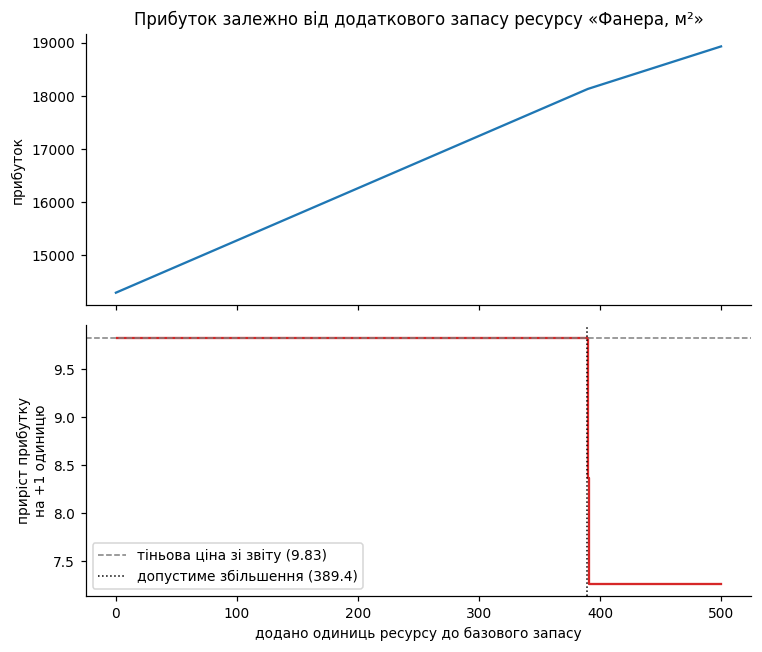

In [9]:
КРОК_МАКС = 500                                   # дивимося на 500 одиниць уперед
додано = np.arange(0, КРОК_МАКС + 1)              # 0, 1, 2, ..., 500
прибутки = []
for d in додано:
    bb = b.copy(); bb[k] += d
    прибутки.append(розв_язати(bb)[1])
прибутки = np.array(прибутки)
прирости = np.diff(прибутки)                       # прибуток(d+1) - прибуток(d)

ДОП_ЗБІЛЬШЕННЯ_ЗВІТ = 389.4286                     # зі звіту Excel, рядок «Фанера»
# перший крок, де приріст перестав дорівнювати тіньовій ціні
злам = int(np.where(np.abs(прирости - ТІНЬОВІ_ЗВІТ[k]) > 1e-6)[0][0])
print('Приріст = %.4f до d = %d; крок %d→%d вже інший (%.4f); далі %.4f' % (
      ТІНЬОВІ_ЗВІТ[k], злам, злам, злам + 1, прирости[злам], прирости[-1]))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot(додано, прибутки, color='tab:blue')
ax1.set_ylabel('прибуток')
ax1.set_title('Прибуток залежно від додаткового запасу ресурсу «%s»' % ресурси[k])
ax2.step(додано[1:], прирости, where='post', color='tab:red')
ax2.axhline(ТІНЬОВІ_ЗВІТ[k], ls='--', color='gray', lw=1, label='тіньова ціна зі звіту (%.2f)' % ТІНЬОВІ_ЗВІТ[k])
ax2.axvline(ДОП_ЗБІЛЬШЕННЯ_ЗВІТ, ls=':', color='black', lw=1, label='допустиме збільшення (%.1f)' % ДОП_ЗБІЛЬШЕННЯ_ЗВІТ)
ax2.set_xlabel('додано одиниць ресурсу до базового запасу')
ax2.set_ylabel('приріст прибутку\nна +1 одиницю')
ax2.legend(loc='lower left')
plt.tight_layout(); plt.show()

**Відповідь 5.2:** на нижньому графіку приріст дорівнює 9,8333 (горизонтальна ділянка) приблизно до
389 додаткових одиниць, потім різкий злам: крок 389→390 уже дає 8,37, а далі приріст сталий і
дорівнює 7,27. Тобто межа лежить між 389 і 390, десь біля 389,4, і це **збігається з допустимим
збільшенням зі звіту Excel (389,43)**.

Чому саме так: коли фанери додається, випускаємо більше табуретів, а їм потрібна фурнітура. Залишок
фурнітури 227,17, а кожна додаткова одиниця фанери забирає 0,5833 фурнітури. 227,17 / 0,5833 = 389,43,
і після цього фурнітура теж стає дефіцитною, тож нова фанера приносить менше (7,27).

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [10]:
i = V['ресурс_пропозиції']; ціна = V['ціна_пропозиції']; обсяг = V['обсяг_пропозиції']
y = ТІНЬОВІ_ЗВІТ[i]
print('Ресурс: %s | ціна пропозиції %.1f | тіньова ціна %.4f | обсяг до %d' % (ресурси[i], ціна, y, обсяг))
print('Чиста вигода однієї одиниці: %.4f - %.1f = %.4f' % (y, ціна, y - ціна))

_, база = розв_язати(b)
рядки = []
for d in [0, 1, 100, 200, 389, 390, 500, обсяг]:
    bb = b.copy(); bb[i] += d
    p = розв_язати(bb)[1]
    рядки.append({'куплено': d, 'прибуток до оплати': round(p, 2), 'приріст': round(p - база, 2),
                  'оплата постачальнику': round(ціна * d, 2), 'чистий результат': round(p - база - ціна * d, 2)})
print(pd.DataFrame(рядки).to_string(index=False))

# скільки купувати, щоб чистий результат був найбільшим (перебір 0..обсяг)
def чистий(d):
    bb = b.copy(); bb[i] += d
    return розв_язати(bb)[1] - база - ціна * d
найкраще = max(range(0, обсяг + 1), key=чистий)
print('Оптимальна кількість закупівлі: %d, чистий результат %.2f' % (найкраще, чистий(найкраще)))

Ресурс: Фанера, м² | ціна пропозиції 15.6 | тіньова ціна 9.8333 | обсяг до 778
Чиста вигода однієї одиниці: 9.8333 - 15.6 = -5.7667
 куплено  прибуток до оплати  приріст  оплата постачальнику  чистий результат
       0            14295.33     0.00                   0.0              0.00
       1            14305.17     9.83                  15.6             -5.77
     100            15278.67   983.33                1560.0           -576.67
     200            16262.00  1966.67                3120.0          -1153.33
     389            18120.50  3825.17                6068.4          -2243.23
     390            18128.87  3833.53                6084.0          -2250.47
     500            18928.20  4632.87                7800.0          -3167.13
     778            20694.00  6398.67               12136.8          -5738.13


Оптимальна кількість закупівлі: 0, чистий результат 0.00


**Відповідь 6.1:**

* **Брати чи ні і чому:** **не брати.** Постачальник просить 15,6 за одиницю фанери, а одна додаткова
  одиниця приносить мені лише 9,83 прибутку (тіньова ціна). Отже, на кожній одиниці я втрачаю
  15,6 − 9,83 = 5,77.
* **Скільки купувати:** **нуль.** Купувати вигідно, лише поки тіньова ціна вища за ціну пропозиції,
  а тут вона нижча. Перебір кількостей від 0 до 778 у коді це підтверджує. Для порівняння: якби ціна
  була нижчою за 9,83, купувати можна було б не більше 389 одиниць (допустиме збільшення), бо далі
  тіньова ціна падає до 7,27.
* **Очікуваний виграш:** 0, бо я нічого не купую. Якби взяв усе, що пропонують, мав би збиток.
* **Перевірка прямим розв'язанням:** якщо запас фанери збільшити на 778 (до 1616), прибуток зросте
  на 6398,67 (до 20694,00), але постачальнику треба заплатити 778·15,6 = 12136,80. Чистий результат
  **−5738,13**. Тому пропозицію відхиляю.

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [11]:
ненульових = int(np.sum(план > 1e-6))              # виробів із ненульовим випуском
залишки = b - A @ план                              # невикористаний запас кожного ресурсу
звязних = int(np.sum(залишки < 1e-6))               # ресурси, витрачені повністю
print('залишки ресурсів:', np.round(залишки, 4))

залишки ресурсів: [1002.5       0.      227.1667    0.      926.5   ]


In [12]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** числа **збіглися**: ненульових виробів 2 (табурет і лава) і зв'язних обмежень теж 2
(фанера і верстат).

Чому так: у оптимальній вершині базисних змінних стільки, скільки обмежень (5). З них 2 це ненульові
вироби, а ще 3 це залишки ресурсів, які не витрачені до кінця. Тому ненульових виробів = 5 − 3 =
кількість зв'язних обмежень.

Якби числа не збіглися (зв'язних обмежень більше, ніж ненульових виробів), це означало б
**виродженість** розв'язку: ресурс витрачено повністю, але якась базисна змінна дорівнює нулю. Тоді
тіньові ціни та діапазони у звіті стають неоднозначними, бо той самий план можна описати кількома
базисами. Протилежний випадок (ненульових виробів більше, ніж зв'язних обмежень) у вершині неможливий.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [13]:
x_lp, п_lp = розв_язати(b)                           # 1. без умови цілочисельності
x_окр = np.round(x_lp)                               # 2. округлений план
п_окр = c @ x_окр
перевитрата = A @ x_окр - b                          # > 0 означає порушення обмеження
допустимий = bool(np.all(перевитрата <= 1e-9))
x_ціл, п_ціл = розв_язати(b, цілі=True)              # 3. справжній цілочисельний оптимум

x_floor = np.floor(x_lp + 1e-9)                      # додатково: округлення вниз
п_floor = c @ x_floor

print('1) без цілочисельності:', np.round(x_lp, 4), '| прибуток %.4f' % п_lp)
print('2) округлений:        ', x_окр, '| прибуток %.1f | допустимий: %s' % (п_окр, допустимий))
print('   перевитрата ресурсів (A·x − b):', перевитрата, '→ порушено:',
      [ресурси[j] for j in np.where(перевитрата > 1e-9)[0]])
print('   (округлення вниз:  ', x_floor, '| прибуток %.1f | допустимий: %s)' % (
      п_floor, bool(np.all(A @ x_floor <= b + 1e-9))))
print('3) цілочисельний оптимум:', np.round(x_ціл), '| прибуток %.1f' % п_ціл)
print('   втрата проти LP: %.4f (%.3f%%) | виграш проти округлення вниз: %.1f' % (
      п_lp - п_ціл, 100 * (п_lp - п_ціл) / п_lp, п_ціл - п_floor))

1) без цілочисельності: [  0.       0.     209.5    103.1667] | прибуток 14295.3333
2) округлений:         [  0.   0. 210. 103.] | прибуток 14315.0 | допустимий: False
   перевитрата ресурсів (A·x − b): [-1003.     2.  -226.     0.  -927.] → порушено: ['Фанера, м²']
   (округлення вниз:   [  0.   0. 209. 103.] | прибуток 14264.0 | допустимий: True)
3) цілочисельний оптимум: [ -0.   1. 209. 103.] | прибуток 14280.0
   втрата проти LP: 15.3333 (0.107%) | виграш проти округлення вниз: 16.0


**Відповідь 8.1:**

| Варіант | План (Крісло, Стілець, Табурет, Лава) | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | (0; 0; 209,5; 103,1667) | 14295,33 | так |
| округлений | (0; 0; 210; 103) | 14315 | **ні** (фанери треба 840, а є 838) |
| цілочисельний оптимум | (0; 1; 209; 103) | 14280 | так |

**Висновок:** просто округлювати не можна. Округлений план дає 14315, що навіть більше за оптимум без
цілочисельності, а це неможливо, і це якраз підказка, що він недопустимий: на 210 табуретів потрібно
840 м² фанери, а в нас 838. Якщо округлити вниз (0; 0; 209; 103), план допустимий, але прибуток лише
14264. Справжній цілочисельний оптимум дає 14280 і навіть має інший склад (з'являється один стілець).
Втрата порівняно з розв'язком без цілочисельності всього 15,33 (близько 0,1 %), тож цілочисельність
краще задавати прямо в моделі.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [14]:
# Прізвище «Перхун» → П, Е, Р;  ім'я «Максим» → М, А, К, С.
# УВАГА: відстані нижче — орієнтовні (з пам'яті), ПЕРЕД ЗДАЧЕЮ перевірте їх у Google Maps
# і за потреби підставте свої. Розв'язок і висновки від точних значень не залежать.
постачальники = ['Полтава', 'Енергодар', 'Рівне']
споживачі     = ['Миколаїв', 'Апостолове', 'Київ', 'Суми']
D = np.array([[470, 330, 340, 175],      # з Полтави
              [330, 100, 580, 540],      # з Енергодара
              [680, 780, 330, 610]])     # з Рівного   (км автошляхами)
запас = [30, 20, 25]                     # сума 75
попит = [13, 19, 27, 16]                 # сума 75

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Миколаїв,Апостолове,Київ,Суми
Полтава,470,330,340,175
Енергодар,330,100,580,540
Рівне,680,780,330,610


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [15]:
assert ПУЛП, 'потрібен pulp:  pip install "pulp==3.3.0"'
m_, n_ = D.shape
т = pulp.LpProblem('транспортна', pulp.LpMinimize)
x = [[pulp.LpVariable('x_%d_%d' % (i, j), lowBound=0) for j in range(n_)] for i in range(m_)]
т += pulp.lpSum(D[i, j] * x[i][j] for i in range(m_) for j in range(n_))            # сумарна вартість
for i in range(m_):
    т += pulp.lpSum(x[i][j] for j in range(n_)) == запас[i], 'пост_%d' % i          # вивезти весь запас
for j in range(n_):
    т += pulp.lpSum(x[i][j] for i in range(m_)) == попит[j], 'спож_%d' % j          # задовольнити попит
т.solve(pulp.PULP_CBC_CMD(msg=0))

X1 = np.array([[x[i][j].value() for j in range(n_)] for i in range(m_)])
вартість1 = pulp.value(т.objective)
u1 = np.array([т.constraints['пост_%d' % i].pi for i in range(m_)])                  # тіньові ціни постачальників
v1 = np.array([т.constraints['спож_%d' % j].pi for j in range(n_)])                  # тіньові ціни споживачів

print('pulp (CBC) — вартість: %.1f' % вартість1)
print(pd.DataFrame(X1, index=постачальники, columns=споживачі).round(2).to_string())
print('тіньові ціни постачальників:', u1)
print('тіньові ціни споживачів:    ', v1)

pulp (CBC) — вартість: 19600.0
           Миколаїв  Апостолове  Київ  Суми
Полтава        12.0         0.0   2.0  16.0
Енергодар       1.0        19.0   0.0   0.0
Рівне           0.0         0.0  25.0   0.0
тіньові ціни постачальників: [175.  35. 165.]
тіньові ціни споживачів:     [295.  65. 165.   0.]


In [16]:
# рівності:  Σⱼ xᵢⱼ = запасᵢ  (3 рядки),  Σᵢ xᵢⱼ = попитⱼ  (4 рядки);  змінні — x[i,j] у вигляді вектора з 12 елементів
A_eq = np.zeros((m_ + n_, m_ * n_))
for i in range(m_):
    for j in range(n_):
        A_eq[i, i * n_ + j] = 1            # рядок постачальника i
        A_eq[m_ + j, i * n_ + j] = 1       # рядок споживача j
b_eq = np.array(list(запас) + list(попит), float)

р = linprog(D.ravel().astype(float), A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
assert р.success, р.message
X2 = р.x.reshape(m_, n_)
вартість2 = р.fun
u2 = р.eqlin.marginals[:m_]
v2 = р.eqlin.marginals[m_:]

print('linprog (HiGHS) — вартість: %.1f' % вартість2)
print(pd.DataFrame(X2, index=постачальники, columns=споживачі).round(2).to_string())
print('тіньові ціни постачальників:', u2)
print('тіньові ціни споживачів:    ', v2)

linprog (HiGHS) — вартість: 19600.0
           Миколаїв  Апостолове  Київ  Суми
Полтава        12.0         0.0   2.0  16.0
Енергодар       1.0        19.0   0.0   0.0
Рівне           0.0         0.0  25.0   0.0
тіньові ціни постачальників: [  -0. -140.  -10.]
тіньові ціни споживачів:     [470. 240. 340. 175.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [17]:
print('вартість однакова:', np.isclose(вартість1, вартість2), '| плани однакові:', np.allclose(X1, X2))
print('тіньові ціни однакові:', np.allclose(np.r_[u1, v1], np.r_[u2, v2]))
print()
print('різниця pulp − linprog, постачальники:', u1 - u2)
print('різниця pulp − linprog, споживачі:     ', v1 - v2)
print()
# що саме збігається в обох розв'язках
print('u_i + v_j однакові в обох:    ', np.allclose(u1[:, None] + v1[None, :], u2[:, None] + v2[None, :]))
print('Σ запас·u + Σ попит·v = вартість:  %.1f і %.1f' % (np.dot(запас, u1) + np.dot(попит, v1),
                                                         np.dot(запас, u2) + np.dot(попит, v2)))
print('ранг матриці обмежень: %d (обмежень %d)' % (np.linalg.matrix_rank(A_eq), A_eq.shape[0]))

вартість однакова: True | плани однакові: True
тіньові ціни однакові: False

різниця pulp − linprog, постачальники: [175. 175. 175.]
різниця pulp − linprog, споживачі:      [-175. -175. -175. -175.]

u_i + v_j однакові в обох:     True
Σ запас·u + Σ попит·v = вартість:  19600.0 і 19600.0
ранг матриці обмежень: 6 (обмежень 7)


**Відповідь 10.2:**

* **Вартість у двох розв'язувачів:** однакова, **19 600**, плани перевезень теж однакові.
* **Тіньові ціни:** **не збіглися.** pulp: постачальники (175; 35; 165), споживачі (295; 65; 165; 0).
  linprog (HiGHS): постачальники (0; −140; −10), споживачі (470; 240; 340; 175).
* **Закономірність:** pulp − linprog дає **+175 для всіх трьох постачальників** і **−175 для всіх
  чотирьох споживачів**. Тобто один набір дістається з іншого додаванням однієї константи до цін
  постачальників і відніманням її від цін споживачів. Сума uᵢ + vⱼ при цьому не змінюється, тому
  вартість і оптимальність зберігаються.
* **Що це означає для того, хто ухвалює рішення:** обидві відповіді правильні. Причина в тому, що в
  збалансованій задачі одне обмеження зайве (сума запасів дорівнює сумі попиту, ранг матриці 6 при
  7 обмеженнях), і двоїстий розв'язок визначений лише з точністю до такого зсуву. Тому окрему
  тіньову ціну («одиниця запасу Полтави коштує 175») читати не можна: її значення залежить від
  розв'язувача. Надійні лише різниці між постачальниками (наприклад, Полтава − Енергодар = 140 в обох) чи
  між споживачами. Збільшити запас окремо від попиту теж не можна, бо порушиться баланс.

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [18]:
ненульових_перевезень = int(np.sum(X2 > 1e-6))
рези = A_eq @ X2.ravel() - b_eq                       # для рівностей це завжди 0
звязних_транс = int(np.sum(np.abs(рези) < 1e-6))       # рівності зв'язні за означенням
print('ненульових перевезень:', ненульових_перевезень)
print('зв’язних обмежень:    ', звязних_транс, 'з', A_eq.shape[0])
print('ранг матриці обмежень:', np.linalg.matrix_rank(A_eq), '= 3 + 4 − 1')
print('різниця: %d' % (звязних_транс - ненульових_перевезень))

ненульових перевезень: 6
зв’язних обмежень:     7 з 7
ранг матриці обмежень: 6 = 3 + 4 − 1
різниця: 1


**Відповідь 11.1:**

* **Ненульових перевезень:** 6.
* **Зв'язних обмежень:** 7, тобто всі.
* **Чому зв'язні всі:** усі обмеження тут рівності: весь запас має бути вивезений і весь попит
  задоволений. Рівність виконується «до кінця» за означенням, тому залишків ресурсу не буває.
* **На скільки ненульових перевезень менше і чому:** на **1** (6 замість 7). Одне обмеження зайве:
  якщо виконано всі рівності для постачальників і три з чотирьох для споживачів, остання виконується
  сама, бо сума запасів дорівнює сумі попиту. Тому ранг системи 3 + 4 − 1 = 6, і в невиродженому
  розв'язку рівно 6 ненульових перевезень. Через це перевірка «ненульових = зв'язних» з етапу 7 тут
  не спрацьовує, а та сама залежність пояснює неоднозначні тіньові ціни з етапу 10.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

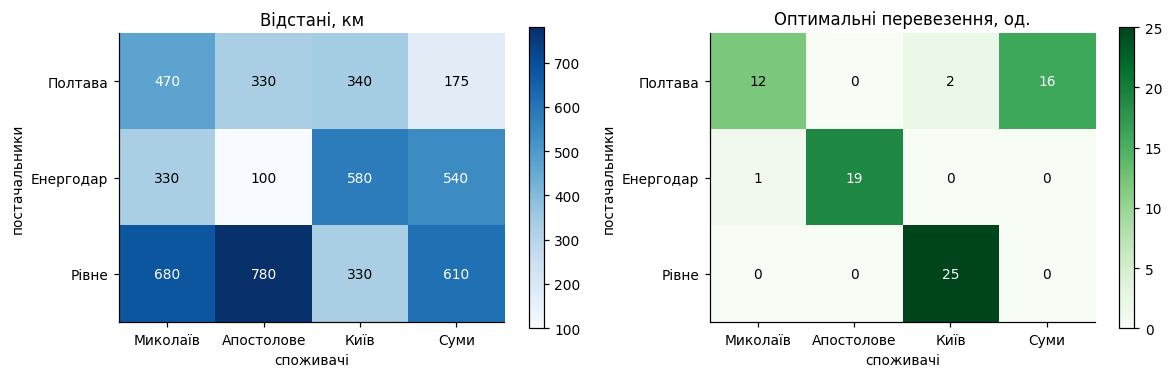

In [19]:
fig, осі = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, M_, назва, кмап in [(осі[0], D, 'Відстані, км', 'Blues'), (осі[1], X2, 'Оптимальні перевезення, од.', 'Greens')]:
    im = ax.imshow(M_, cmap=кмап)
    ax.set_xticks(range(len(споживачі))); ax.set_xticklabels(споживачі)
    ax.set_yticks(range(len(постачальники))); ax.set_yticklabels(постачальники)
    ax.set_xlabel('споживачі'); ax.set_ylabel('постачальники'); ax.set_title(назва)
    for i in range(M_.shape[0]):
        for j in range(M_.shape[1]):
            знач = M_[i, j]
            ax.text(j, i, '%g' % round(знач, 2), ha='center', va='center',
                    color='white' if знач > 0.6 * M_.max() else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

**Висновок:** на картах видно, що велика частина перевезень іде найкоротшими маршрутами (Рівне → Київ 25,
Енергодар → Апостолове 19, Полтава → Суми 16), а довгі маршрути (Рівне → Апостолове/Суми,
Енергодар → Київ/Суми) порожні; ненульових клітинок усього шість.

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [20]:
ІНСТРУМЕНТИ_ШІ = 'Claude (Anthropic)'

# Значення нижче — запропоновані за фактом (чернетку коду й текстів згенеровано Claude).
# Змініть кожне, якщо вийшло інакше: наприклад, після того як ви самі переписали текст по суті,
# ставте 'текст, перероблено'. Чесність важливіша за «красивий» варіант.
ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'текст, як є',
    'етап 2, побудова моделі в Excel':      'код, перевірено',
    'етап 3, код на Python':                'код, перевірено',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# ЗАПОВНІТЬ САМІ (щонайменше 120 символів): що саме ви перевірили за згенерованим кодом чи текстом.
ЩО_ПЕРЕВІРЕНО = ''

# True — лише коли ви справді можете пояснити кожен рядок і відтворити будь-яке число.
ПІДТВЕРДЖУЮ = False

In [21]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

AssertionError: Опишіть конкретніше (зараз 0 символів, потрібно щонайменше 120)

---
# Крок 13. Фінальна самоперевірка

In [22]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
НЕ ОК  декларацію заповнено
